<a href="https://colab.research.google.com/github/jose-luis-hernandez-amaya/Simulaci-n-1/blob/main/Distribucion_de_Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de una variable aleatoria Poisson

Una variable de X es *Poisson* con media $\lambda$ si:
$$P_i = p\{x=i\} = e^{-\lambda}\frac{\lambda^i}{i!},\qquad  i=0,1$$

Queremos encontrar la probabilidad del siguiente valor sucesivo. Sustituimos $i$ por $i+1$ en la fórmula original:$$p_{i+1} = e^{-\lambda} \frac{\lambda^{i+1}}{(i+1)!}$$

$$p_{i+1} = e^{-\lambda} \frac{\lambda \cdot \lambda^i}{(i+1) \cdot i!}$$

$$p_{i+1} = \frac{\lambda}{i+1} \left( e^{-\lambda} \frac{\lambda^i}{i!} \right)$$

$$p_{i+1} = \frac{\lambda}{i+1} p_i, \qquad i\geq 0$$

para aplicar el método de la transformación inversa

Y sirve para que la computadora no explote, ya que si no, tendra que calcular por ejemplo $50^{120}$ o $120!$

Con $$p_{i+1} = \frac{\lambda}{i+1} p_i$$ se toman pasos pequeños y se ahorra la memoria

# Codigo

In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [10]:
def simular_poisson_recursivo(lam):
    u = random.random()

    i = 0
    p = np.exp(-lam)
    F = p

    while u >= F:
        i += 1
        p = p * (lam / i)
        F += p
    return i

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1127/759658206.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson ($\lambda$ = {lam_objetivo})', fontsize=14)


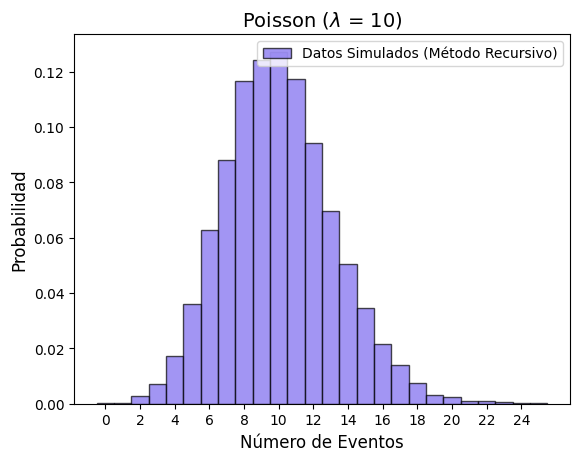

In [11]:
lam_objetivo = 10
iteraciones = 10000
muestra_poisson = [simular_poisson_recursivo(lam_objetivo) for _ in range(iteraciones)]

plt.hist(muestra_poisson, bins=np.arange(0, max(muestra_poisson) + 2) - 0.5,
         density=True, color='mediumslateblue', edgecolor='black', alpha=0.7,
         label='Datos Simulados (Método Recursivo)')

plt.xlabel('Número de Eventos', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title(f'Poisson ($\lambda$ = {lam_objetivo})', fontsize=14)
plt.xticks(range(0, max(muestra_poisson) + 1, 2))
plt.legend()
plt.show()

In [12]:
media_simulada = np.mean(muestra_poisson)
print(f"Media teórica esperada (Lambda): {lam_objetivo}")
print(f"Media real de la simulación: {media_simulada:.4f}")

Media teórica esperada (Lambda): 10
Media real de la simulación: 10.0305
